# 02 · Análisis de la demanda

**Trabajo Fin de Máster** · Predicción de demanda en hostelería
Juan Francisco Morales Olivo

---

Este notebook busca los patrones que sigue la demanda del restaurante, antes de plantear ningún modelo.

El objetivo no es solo describir: es decidir **qué variables merece la pena construir**. Cada patrón que se encuentre aquí tiene que convertirse en una columna que el modelo pueda usar.

In [1]:
# ============================================================
# CONFIGURACIÓN DEL NOTEBOOK
# ============================================================

import sys
from pathlib import Path

# Permite importar `src` desde la carpeta notebooks/
RAIZ = Path.cwd()

if not (RAIZ / "src").exists():
    RAIZ = RAIZ.parent

if str(RAIZ) not in sys.path:
    sys.path.insert(0, str(RAIZ))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 40)

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

print("Proyecto:", RAIZ)

Proyecto: /home/claude/tfm


In [2]:
from src.config import GOLD_DATASET

gold = pd.read_csv(GOLD_DATASET, parse_dates=["fecha"])

ORDEN_DIAS = ["Lunes", "Martes", "Miércoles", "Jueves", "Viernes", "Sábado", "Domingo"]

print(f"{len(gold)} días de actividad, de {gold['fecha'].min().date()} a {gold['fecha'].max().date()}")

1138 días de actividad, de 2022-01-01 a 2026-09-11


## 1. El día de la semana

Es el primer sitio donde mirar, y en hostelería suele ser también el más importante.

In [3]:
por_dia = (
    gold
    .groupby("nombre_dia")["n_clientes"]
    .agg(["count", "mean", "std", "min", "max"])
    .reindex([d for d in ORDEN_DIAS if d in gold["nombre_dia"].unique()])
    .round(1)
)

por_dia.columns = ["días", "media", "desviación", "mínimo", "máximo"]

print("CLIENTES POR DÍA DE LA SEMANA")
print("-" * 60)
print(por_dia.to_string())

print()
print(f"El sábado tiene {por_dia.loc['Sábado', 'media'] / por_dia.loc['Miércoles', 'media']:.1f} veces")
print("más clientes que el miércoles.")

CLIENTES POR DÍA DE LA SEMANA
------------------------------------------------------------
            días  media  desviación  mínimo  máximo
nombre_dia                                         
Lunes         18   53.9        12.9      31      81
Martes        18   60.9        15.7      36      89
Miércoles    219   52.8        11.3      32      95
Jueves       220   72.0        17.3      31     125
Viernes      222  106.5        25.2      52     187
Sábado       221  152.2        39.6      51     277
Domingo      220  122.9        29.5      47     204

El sábado tiene 2.9 veces
más clientes que el miércoles.


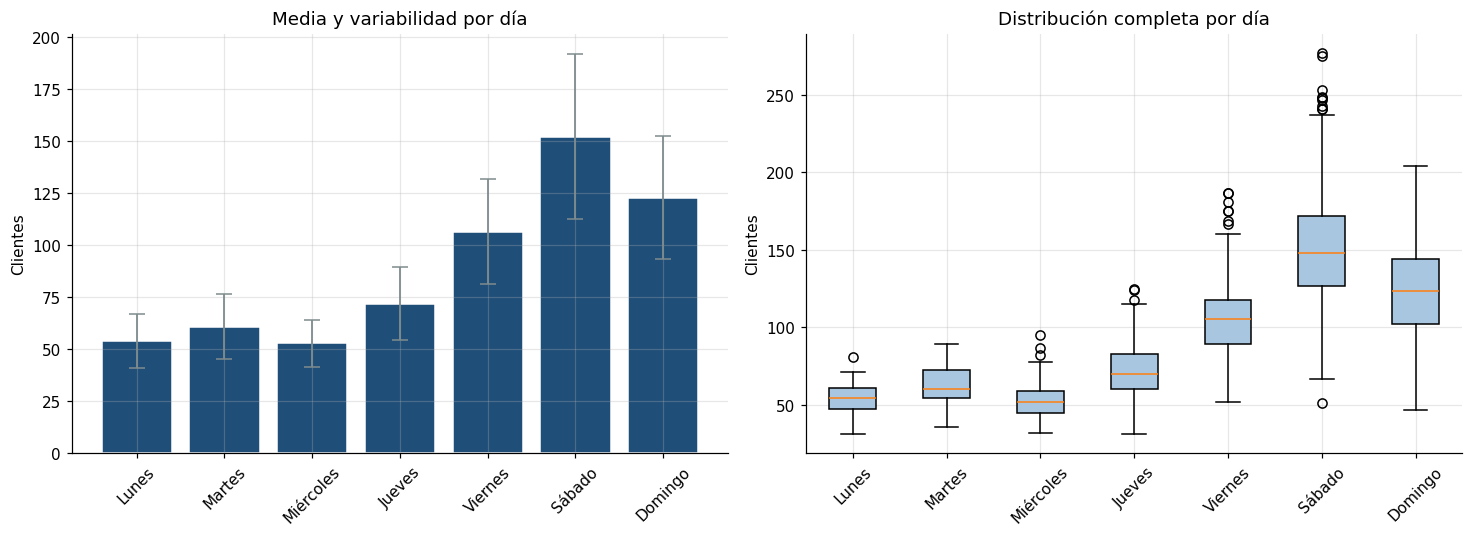

In [4]:
figura, ejes = plt.subplots(1, 2, figsize=(13.5, 5))

ejes[0].bar(por_dia.index, por_dia["media"], yerr=por_dia["desviación"],
            capsize=5, color="#1f4e79", edgecolor="white",
            error_kw={"ecolor": "#7f8c8d", "linewidth": 1.2})
ejes[0].set_title("Media y variabilidad por día")
ejes[0].set_ylabel("Clientes")
ejes[0].tick_params(axis="x", rotation=45)

datos_caja = [
    gold[gold["nombre_dia"] == dia]["n_clientes"].values
    for dia in por_dia.index
]

caja = ejes[1].boxplot(datos_caja, tick_labels=list(por_dia.index), patch_artist=True)

for pieza in caja["boxes"]:
    pieza.set_facecolor("#a8c6e0")

ejes[1].set_title("Distribución completa por día")
ejes[1].set_ylabel("Clientes")
ejes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

El patrón es muy marcado y ordena la semana en tres bloques:

- **Miércoles y jueves**: los días flojos, con la clientela más previsible.
- **Viernes**: el arranque del fin de semana.
- **Sábado y domingo**: el grueso del negocio.

Los lunes y martes casi no aparecen porque el restaurante cierra: solo hay datos cuando caen en vacaciones o en festivo.

Un detalle importante para el modelo: **la desviación también crece con la media**. El sábado no solo trae más gente, sino que es más impredecible. Eso significa que el error absoluto del modelo será mayor en fin de semana por pura aritmética, y hay que tenerlo en cuenta al interpretar las métricas.

## 2. Estacionalidad

¿Qué meses son mejores?

In [5]:
NOMBRES_MESES = {
    1: "enero", 2: "febrero", 3: "marzo", 4: "abril", 5: "mayo", 6: "junio",
    7: "julio", 8: "agosto", 9: "septiembre", 10: "octubre", 11: "noviembre", 12: "diciembre",
}

por_mes = (
    gold
    .groupby("mes")["n_clientes"]
    .agg(["count", "mean"])
    .round(1)
)

por_mes.index = [NOMBRES_MESES[m] for m in por_mes.index]
por_mes.columns = ["días", "media"]

print("CLIENTES POR MES")
print("-" * 40)
print(por_mes.to_string())

print()
print("Agosto no aparece: el restaurante cierra por vacaciones.")

CLIENTES POR MES
----------------------------------------
            días  media
enero        120   74.5
febrero      101   81.2
marzo        114   88.8
abril        113  110.4
mayo         112  113.2
junio        107  116.3
julio        111  113.5
septiembre    97   97.1
octubre       88  104.9
noviembre     88   93.9
diciembre     87  108.0

Agosto no aparece: el restaurante cierra por vacaciones.


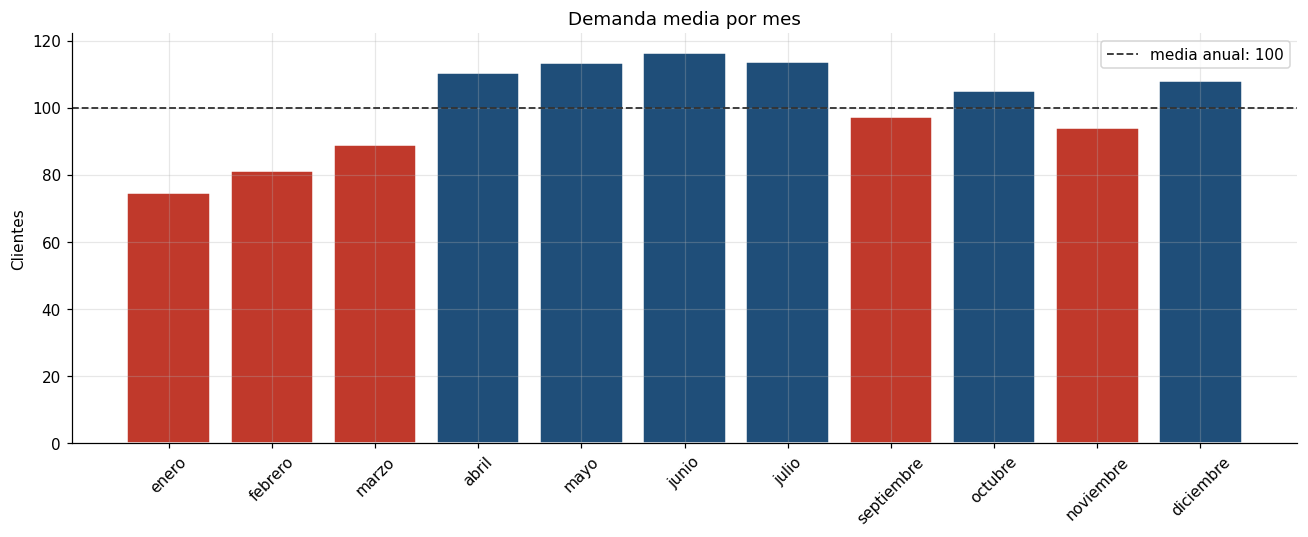

In [6]:
media_global = gold["n_clientes"].mean()

figura, eje = plt.subplots(figsize=(12, 5))

colores = ["#c0392b" if v < media_global else "#1f4e79" for v in por_mes["media"]]

eje.bar(por_mes.index, por_mes["media"], color=colores, edgecolor="white")

eje.axhline(media_global, color="#333333", linestyle="--", linewidth=1.2,
            label=f"media anual: {media_global:.0f}")

eje.set_title("Demanda media por mes")
eje.set_ylabel("Clientes")
eje.tick_params(axis="x", rotation=45)
eje.legend()

plt.tight_layout()
plt.show()

Diciembre y julio destacan claramente. Diciembre por las comidas de empresa y las fiestas; julio por la temporada de terraza.

Enero y febrero son los meses más flojos, lo cual encaja: hace frío y la gente sale menos.

## 3. El cruce que importa: día × mes

Los dos efectos anteriores no son independientes. Un sábado de julio no es lo mismo que un sábado de febrero, y la diferencia no es simplemente la suma de "sábado" más "julio".

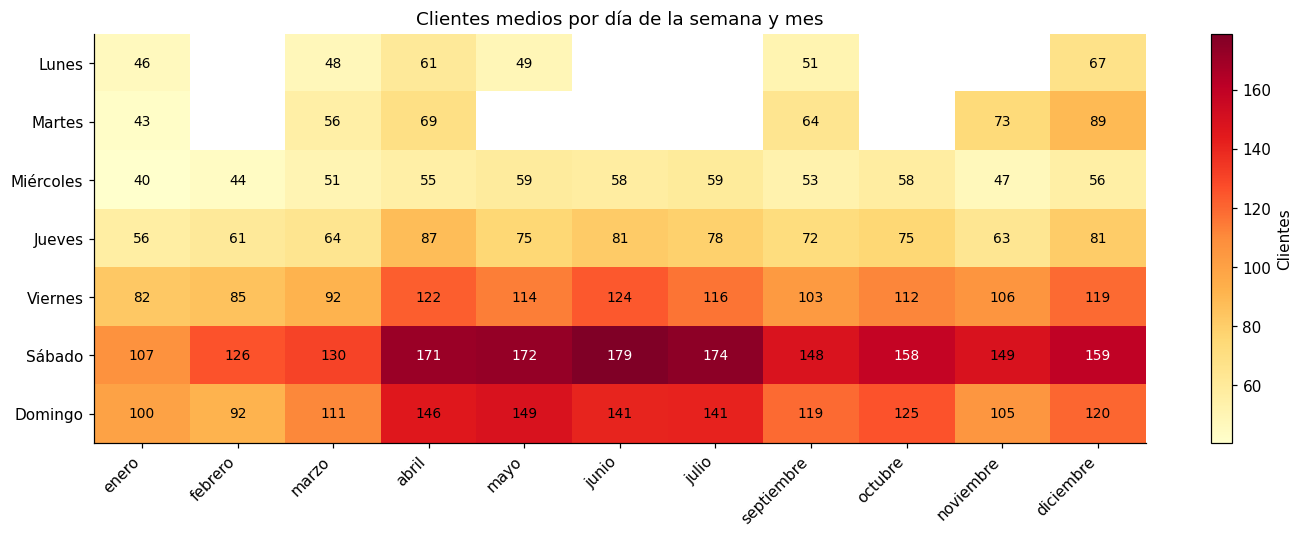

In [7]:
tabla = gold.pivot_table(
    index="nombre_dia",
    columns="mes",
    values="n_clientes",
    aggfunc="mean",
).reindex([d for d in ORDEN_DIAS if d in gold["nombre_dia"].unique()])

tabla.columns = [NOMBRES_MESES[m] for m in tabla.columns]

figura, eje = plt.subplots(figsize=(13, 5))

imagen = eje.imshow(tabla.values, cmap="YlOrRd", aspect="auto")

eje.set_xticks(range(len(tabla.columns)))
eje.set_xticklabels(tabla.columns, rotation=45, ha="right")
eje.set_yticks(range(len(tabla.index)))
eje.set_yticklabels(tabla.index)

for i in range(len(tabla.index)):
    for j in range(len(tabla.columns)):
        valor = tabla.values[i, j]
        if not np.isnan(valor):
            eje.text(j, i, f"{valor:.0f}", ha="center", va="center",
                     fontsize=9, color="black" if valor < 150 else "white")

eje.set_title("Clientes medios por día de la semana y mes")
eje.grid(False)

figura.colorbar(imagen, ax=eje, label="Clientes")

plt.tight_layout()
plt.show()

El mapa deja ver la interacción: los fines de semana de mayo, junio y julio están más cargados que los del resto del año, mientras que entre semana la diferencia estacional es mucho menor.

**Esto es exactamente lo que un modelo lineal no puede aprender solo con efectos principales.** Si le doy "es sábado" y "es junio" por separado, solo puede sumar los dos efectos; no puede saber que la combinación vale más que la suma.

Ahora bien: que la interacción se vea en el mapa no significa que meterla en el modelo mejore la predicción. Son dos preguntas distintas, y la segunda hay que medirla.

Una versión anterior del proyecto no la midió: el calendario publicaba `es_fin_semana_mayo`, `es_fin_semana_junio` y `es_fin_semana_julio` directamente. Tres meses elegidos a mano, y elegidos además por el motivo equivocado — eran los tres meses que el generador sintético amplifica, no los que más destacan en los datos. La ratio findes/laborables más alta de la serie está en noviembre (1,955) y abril (1,913), por encima de mayo (1,839).

La versión actual plantea la interacción para los doce meses (`mes_finde`, en `src/models/features.py`) y la compara contra el conjunto de efectos principales en `src/analysis/comparar_variables.py`. El resultado: baja el MAE de validación cruzada de 15,12 a 14,75, una diferencia que cabe holgadamente dentro de la desviación típica entre bloques (0,86), a cambio de veintiuna columnas más. No supera el umbral, así que se despliega el conjunto simple.

Conviene entender qué dice y qué no dice ese resultado. **No** dice que la interacción no exista: el generador la produce, entre un 5 % y un 8 % en los fines de semana de esos meses. Dice que un efecto de ese tamaño, con unas 1.100 observaciones, es más pequeño que el error de estimar las columnas que hacen falta para capturarlo.

In [8]:
print("EFECTO DEL FIN DE SEMANA SEGÚN EL MES")
print("-" * 60)
print(f"{'mes':<12} {'entre semana':>14} {'fin de semana':>15} {'diferencia':>12}")
print("-" * 60)

for mes in sorted(gold["mes"].unique()):
    datos = gold[gold["mes"] == mes]

    entre = datos[datos["fin_de_semana"] == 0]["n_clientes"].mean()
    finde = datos[datos["fin_de_semana"] == 1]["n_clientes"].mean()

    print(f"{NOMBRES_MESES[mes]:<12} {entre:>14.0f} {finde:>15.0f} {finde - entre:>12.0f}")

EFECTO DEL FIN DE SEMANA SEGÚN EL MES
------------------------------------------------------------
mes            entre semana   fin de semana   diferencia
------------------------------------------------------------
enero                    58             104           46
febrero                  63             109           45
marzo                    68             120           52
abril                    84             159           75
mayo                     83             161           78
junio                    87             159           72
julio                    84             158           73
septiembre               76             134           58
octubre                  81             141           60
noviembre                72             128           56
diciembre                86             140           54


La diferencia entre semana y fin de semana no es constante: oscila de forma apreciable a lo largo del año. Eso confirma que la interacción existe y que merece la pena modelarla.

## 4. Festivos y vacaciones

In [9]:
print("EFECTO DE LOS FESTIVOS")
print("-" * 50)

normal = gold[gold["es_festivo"] == 0]["n_clientes"].mean()
festivo = gold[gold["es_festivo"] == 1]["n_clientes"].mean()

print(f"  Día normal:  {normal:.1f} clientes")
print(f"  Día festivo: {festivo:.1f} clientes")
print(f"  Diferencia:  {100 * (festivo / normal - 1):+.1f} %")
print(f"  (sobre {int((gold['es_festivo'] == 1).sum())} días festivos)")

print()
print("EFECTO DEL PERIODO VACACIONAL")
print("-" * 50)

por_vacaciones = (
    gold
    .groupby("tipo_vacaciones")["n_clientes"]
    .agg(["count", "mean"])
    .round(1)
    .sort_values("mean", ascending=False)
)

por_vacaciones.columns = ["días", "media"]

print(por_vacaciones.to_string())

EFECTO DE LOS FESTIVOS
--------------------------------------------------
  Día normal:  100.0 clientes
  Día festivo: 98.7 clientes
  Diferencia:  -1.3 %
  (sobre 54 días festivos)

EFECTO DEL PERIODO VACACIONAL
--------------------------------------------------
                 días  media
tipo_vacaciones             
semana_santa       71  115.9
ninguna          1032   99.9
navidad            35   70.5


Cuidado al leer estas cifras: **están confundidas con el día de la semana**. Un festivo puede caer en sábado, y entonces no sabemos cuánto del efecto es del festivo y cuánto del sábado.

Para aislarlo hay que comparar dentro del mismo día de la semana.

In [10]:
print("EFECTO DEL FESTIVO, CONTROLANDO EL DÍA DE LA SEMANA")
print("-" * 62)
print(f"{'día':<12} {'normal':>10} {'festivo':>10} {'diferencia':>12} {'n festivos':>12}")
print("-" * 62)

for dia in ORDEN_DIAS:
    datos = gold[gold["nombre_dia"] == dia]

    normales = datos[datos["es_festivo"] == 0]["n_clientes"]
    festivos = datos[datos["es_festivo"] == 1]["n_clientes"]

    if len(festivos) < 3 or len(normales) < 3:
        continue

    diferencia = 100 * (festivos.mean() / normales.mean() - 1)

    print(f"{dia:<12} {normales.mean():>10.0f} {festivos.mean():>10.0f} "
          f"{diferencia:>11.0f} % {len(festivos):>12}")

EFECTO DEL FESTIVO, CONTROLANDO EL DÍA DE LA SEMANA
--------------------------------------------------------------
día              normal    festivo   diferencia   n festivos
--------------------------------------------------------------
Lunes                52         57           8 %            6
Martes               59         66          12 %            5
Miércoles            53         59          12 %            6
Jueves               71         84          19 %           12
Viernes             105        124          17 %           13
Sábado              152        146          -4 %            7
Domingo             123        133           9 %            5


Controlando el día de la semana, el efecto del festivo se mantiene positivo pero es más moderado de lo que sugería la comparación cruda. Es un recordatorio de por qué conviene no fiarse de las medias simples cuando las variables están relacionadas entre sí.

## 5. La tendencia

In [11]:
por_año = gold.groupby("año")["n_clientes"].agg(["count", "mean"]).round(1)
por_año.columns = ["días", "media"]

print("EVOLUCIÓN ANUAL")
print("-" * 40)
print(por_año.to_string())

# Ajuste de una recta sobre el tiempo.
dias = (gold["fecha"] - gold["fecha"].min()).dt.days

pendiente, interseccion = np.polyfit(dias, gold["n_clientes"], 1)

print()
print(f"Tendencia: {pendiente * 365:+.1f} clientes al año")
print(f"Sobre una media de {gold['n_clientes'].mean():.0f}, es un {100 * pendiente * 365 / gold['n_clientes'].mean():+.1f} % anual")

EVOLUCIÓN ANUAL
----------------------------------------
      días  media
año              
2022   248   93.0
2023   234   96.0
2024   243  103.4
2025   246  103.9
2026   167  105.3

Tendencia: +4.5 clientes al año
Sobre una media de 100, es un +4.5 % anual


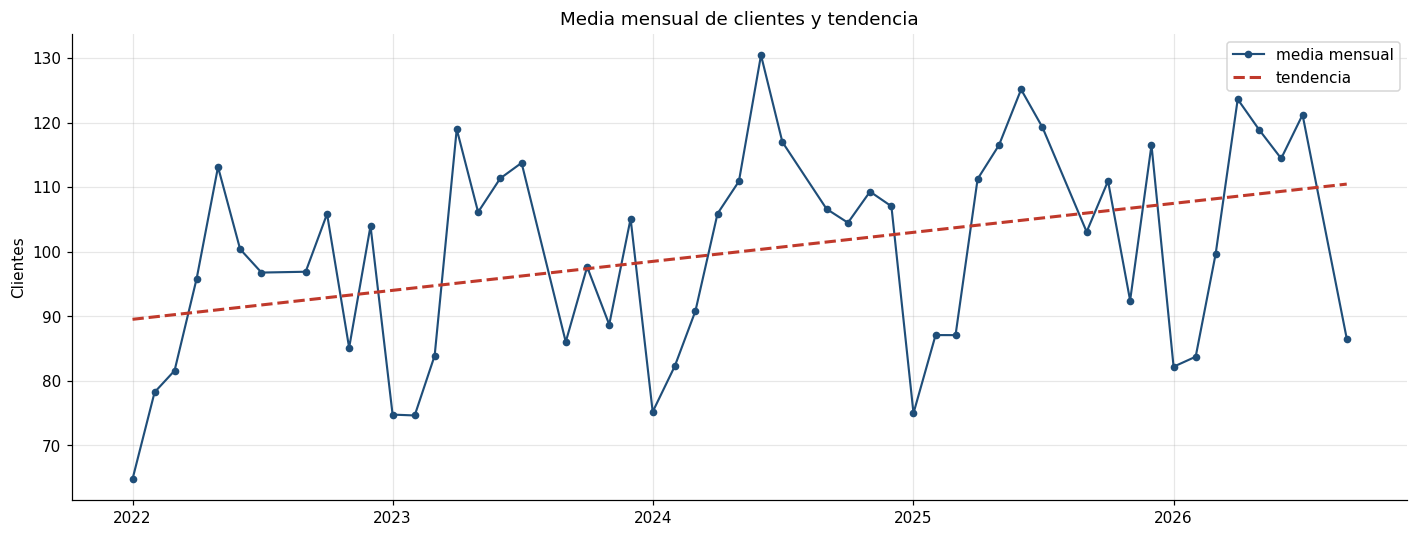

In [12]:
media_mensual = (
    gold
    .set_index("fecha")["n_clientes"]
    .resample("MS")
    .mean()
    .dropna()
)

figura, eje = plt.subplots(figsize=(13, 5))

eje.plot(media_mensual.index, media_mensual.values, marker="o",
         markersize=4, linewidth=1.4, color="#1f4e79", label="media mensual")

fechas_recta = pd.date_range(gold["fecha"].min(), gold["fecha"].max(), freq="MS")
dias_recta = (fechas_recta - gold["fecha"].min()).days

eje.plot(fechas_recta, pendiente * dias_recta + interseccion,
         color="#c0392b", linestyle="--", linewidth=2, label="tendencia")

eje.set_title("Media mensual de clientes y tendencia")
eje.set_ylabel("Clientes")
eje.legend()

plt.tight_layout()
plt.show()

El negocio crece de forma sostenida, alrededor de un 4 % anual.

Esto plantea un problema concreto para el modelado que conviene anticipar: **los modelos de árboles no pueden extrapolar una tendencia**. Un árbol solo sabe dividir el espacio en regiones y predecir la media de cada una; si le llegan datos de un periodo posterior a todo lo que ha visto, no tiene forma de saber que los valores deberían ser más altos.

Se verá en el notebook 04, donde el modelo se queda corto de forma sistemática al predecir 2026 habiendo aprendido de 2022-2024.

## 6. La plantilla

`n_empleados` está en los datos. ¿Debería usarla el modelo?

In [13]:
print("EMPLEADOS POR DÍA DE LA SEMANA")
print("-" * 50)

print(
    gold.groupby("nombre_dia")["n_empleados"]
    .agg(["mean", "min", "max"])
    .reindex([d for d in ORDEN_DIAS if d in gold["nombre_dia"].unique()])
    .round(1)
    .to_string()
)

correlacion = gold[["n_empleados", "n_clientes"]].corr().iloc[0, 1]

print()
print(f"Correlación entre empleados y clientes: {correlacion:.3f}")

EMPLEADOS POR DÍA DE LA SEMANA
--------------------------------------------------
            mean  min  max
nombre_dia                
Lunes        5.7    3    7
Martes       5.8    3    7
Miércoles    4.4    3    7
Jueves       4.7    3    7
Viernes      4.7    3    7
Sábado       7.0    6    8
Domingo      7.0    6    8

Correlación entre empleados y clientes: 0.519


La correlación es alta, pero eso no significa que la variable sirva.

La plantilla se decide **a partir del día de la semana**: los sábados se ponen más camareros. Es decir, `n_empleados` no aporta ninguna información que el modelo no tenga ya a través de `dia_semana`; solo la repite con ruido añadido.

Y hay una razón de producto todavía más importante. La dirección útil para el negocio es la contraria:

> No quiero predecir clientes a partir de la plantilla. Quiero predecir clientes **para decidir** la plantilla.

Usar `n_empleados` como entrada haría el sistema circular: para saber cuánta gente viene tendría que haber decidido ya a cuánta gente llamo. Por eso **queda fuera del conjunto de variables del modelo** y se reserva para la salida: la recomendación de personal.

In [14]:
print("RATIO DE CLIENTES POR EMPLEADO Y NOTA DE LA JORNADA")
print("-" * 58)

gold_ratio = gold.copy()
gold_ratio["ratio"] = gold_ratio["n_clientes"] / gold_ratio["n_empleados"]

print(
    gold_ratio.groupby("nota_faena")["ratio"]
    .agg(["count", "mean", "min", "max"])
    .round(1)
    .sort_values("mean")
    .to_string()
)

print()
print("Estos umbrales son los que usa la aplicación para recomendar plantilla:")
print("  más de 24 clientes por empleado -> falta de personal")
print("  entre 15 y 24                   -> personal ocupado")
print("  menos de 15                     -> personal ocioso")

RATIO DE CLIENTES POR EMPLEADO Y NOTA DE LA JORNADA
----------------------------------------------------------
                         count  mean   min   max
nota_faena                                      
personal sin hacer nada    282  11.3   5.7  14.9
personal suficiente        286  15.7   5.5  23.9
personal ocupado           433  21.0  15.0  45.7
falta de personal          137  30.2  24.0  58.3

Estos umbrales son los que usa la aplicación para recomendar plantilla:
  más de 24 clientes por empleado -> falta de personal
  entre 15 y 24                   -> personal ocupado
  menos de 15                     -> personal ocioso


## Conclusiones

1. **El día de la semana es, con diferencia, el factor dominante.** Un sábado triplica la demanda de un miércoles.

2. **La variabilidad crece con la demanda.** El error absoluto del modelo será mayor en fin de semana; no es un defecto, es la naturaleza del dato.

3. **Hay interacción entre el día y el mes.** Los fines de semana de mayo a julio están especialmente cargados. Se modela con variables de interacción explícitas.

4. **El efecto de los festivos es real pero moderado** una vez se controla el día de la semana.

5. **El negocio crece un 4 % anual**, y eso dará problemas a los modelos de árboles.

6. **`n_empleados` no debe ser una entrada del modelo**: no aporta información nueva y haría el producto circular. Se usa en la salida, para recomendar plantilla.

El siguiente notebook analiza el efecto de la meteorología.